<a href="https://colab.research.google.com/github/gitmystuff/DTSC5502/blob/main/Module_11-Trees/Make_Me_Data_Science_V.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Make Me Data Science V

Name

## Getting Started

* Colab - get notebook from gitmystuff DTSC5502 repository
* Save a Copy in Drive
* Remove Copy of
* Edit your name
* Clean up Colab Notebooks folder
* Submit shared link

### Outline

* Set the Stage
* Create the Data
* Exploratory Data Analysis
* Data Prep
* Feature Engineering
* Feature Selection
* Data Modeling
* Model Evaluation
* Model Fine-Tuning
* Model Deployment

## Set the Stage

See Table of Contents

A Data Scientist’s roles and responsibilities include extracting data from multiple sources, using machine learning tools to organize data, process, clean, and validate the data, analyze the data for information and patterns, develop prediction systems, present the data in a clear manner, and propose solutions and strategies.

https://www.simplilearn.com/data-scientist-job-description-article#:~:text=A%20Data%20Scientist's%20roles%20and,manner%2C%20and%20propose%20solutions%20and

Data cleaning is essential in preparing data for analysis, and it is important to handle potential data errors before presenting results. Comparing model results with and without the data errors allows presentation of graphical evidence to show that data cleaning is worth the time spent.

https://chance.amstat.org/2020/02/data-cleaning/#:~:text=Data%20cleaning%20is%20essential%20in,is%20worth%20the%20time%20spent.

In [1]:
# ! git clone https://github.com/gitmystuff/preppy.git

In [2]:
# # report is required
# import shutil

# # Source file path (within your Drive)
# source_file = '/content/drive/MyDrive/Colab Notebooks/preppy report.py'

# # Destination path (root of your Drive)
# destination_path = '/content/preppy/utils/report.py'

# # Copy the file
# shutil.copy(source_file, destination_path)

## Create the Data

### Seed the Project

In [3]:
# seed
import random

student_id = 123456789
random_state = random.seed(student_id)
random_state

### Faker

In [4]:
pip install Faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 13.7 MB/s eta 0:00:00


In [5]:
state_names=["Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado", "Connecticut", "Delaware", "Florida", "Georgia", "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland", "Massachusetts", "Michigan", "Minnesota", "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada", "New Hampshire", "New Jersey", "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio", "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina", "South Dakota", "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington", "West Virginia", "Wisconsin", "Wyoming"]

In [6]:
# create demographic data
import numpy as np
import pandas as pd
from faker import Faker
fake = Faker()

output = []
for x in range(1000):
  binary = np.random.choice(['binary_1', 'binary_2'], p=[0.5, 0.5])
  output.append({
        'binary': binary, # sex assigned at birth
        'given_name': fake.first_name_female() if binary=='binary_1' else fake.first_name_male(),
        'surname': fake.last_name(),
        'date_of_birth': fake.date_of_birth(),
        'phone_number': fake.phone_number(),
        'email': fake.email(),
        'address': fake.address(),
        'city': fake.city(),
        'state': np.random.choice(state_names),
        'zipcode': fake.zipcode(),
        })

demographics = pd.DataFrame(output)
demographics.head()

,binary,given_name,surname,date_of_birth,phone_number,email,address,city,state,zipcode
0,binary_1,Christina,Henderson,1952-01-09,(350)278-3741x1356,ryantapia@example.com,"82995 Green Forks\nWest Holly, RI 52928",Stephenshire,Maryland,80597
1,binary_2,Bryan,Smith,1926-12-28,001-890-473-5532x99372,ifitzpatrick@example.org,"911 Ryan Shoal Apt. 351\nNorth Heatherberg, KY...",Richardsville,Connecticut,16508
2,binary_2,Kevin,Tucker,1952-02-08,691.679.3920x5234,shannon14@example.com,"474 Gay Bypass Suite 812\nEast Jason, NJ 21311",Robinsonfurt,Massachusetts,44108
3,binary_1,Elizabeth,Horne,1994-06-08,(919)463-4578,kimberly99@example.com,"84780 Robert Park Suite 710\nWest Edwardside, ...",Jeffreyside,Tennessee,12898
4,binary_2,Matthew,Smith,1940-08-08,+1-883-330-2667,robertsvirginia@example.net,"3244 Hudson Field\nEast Bryan, GA 02502",Burkeview,Pennsylvania,70480


In [7]:
def parse_address_v2(text):
  """
  Parses an address string into street address, city, state, and zipcode.
  This version handles potential variations in the input format.

  Args:
    text: The address string to parse.

  Returns:
    A dictionary containing the parsed address components.
  """

  try:
    # Split the input into lines
    lines = text.strip().split('\n')

    # Extract the street address from the first line
    street_address = lines[0].strip()

    # Extract the city, state, and zipcode from the second line
    city_state_zip = lines[1].strip().split(',')
    city = city_state_zip[0].strip()
    state_zip = city_state_zip[1].strip().split()
    state = state_zip[0].strip()
    zipcode = state_zip[1].strip()

    return {
        'street_address': street_address,
        'city': city,
        'state': state,
        'zipcode': zipcode
    }

  except (IndexError, ValueError):
    return None

# Example usage
text = "80974 Jeffrey Mountains\nWest Benjamin, IL 82801"
address = parse_address_v2(text)

if address:
  print(address)
else:
  print("Could not parse the address.")

{'street_address': '80974 Jeffrey Mountains', 'city': 'West Benjamin', 'state': 'IL', 'zipcode': '82801'}


In [8]:
# Apply the parse_address function to each row of the 'address' column
demographics[['nu_address', 'nu_city', 'nu_state', 'nu_zipcode']] = demographics['address'].apply(lambda x: pd.Series(parse_address_v2(x)))

demographics.head()

,binary,given_name,surname,date_of_birth,phone_number,email,address,city,state,zipcode,nu_address,nu_city,nu_state,nu_zipcode
0,binary_1,Christina,Henderson,1952-01-09,(350)278-3741x1356,ryantapia@example.com,"82995 Green Forks\nWest Holly, RI 52928",Stephenshire,Maryland,80597,82995 Green Forks,West Holly,RI,52928
1,binary_2,Bryan,Smith,1926-12-28,001-890-473-5532x99372,ifitzpatrick@example.org,"911 Ryan Shoal Apt. 351\nNorth Heatherberg, KY...",Richardsville,Connecticut,16508,911 Ryan Shoal Apt. 351,North Heatherberg,KY,70082
2,binary_2,Kevin,Tucker,1952-02-08,691.679.3920x5234,shannon14@example.com,"474 Gay Bypass Suite 812\nEast Jason, NJ 21311",Robinsonfurt,Massachusetts,44108,474 Gay Bypass Suite 812,East Jason,NJ,21311
3,binary_1,Elizabeth,Horne,1994-06-08,(919)463-4578,kimberly99@example.com,"84780 Robert Park Suite 710\nWest Edwardside, ...",Jeffreyside,Tennessee,12898,84780 Robert Park Suite 710,West Edwardside,MO,45755
4,binary_2,Matthew,Smith,1940-08-08,+1-883-330-2667,robertsvirginia@example.net,"3244 Hudson Field\nEast Bryan, GA 02502",Burkeview,Pennsylvania,70480,3244 Hudson Field,East Bryan,GA,02502


In [9]:
# drop address, city, state, zipcode and rename nu_ etc.
demographics.drop(['address', 'city', 'state', 'zipcode'], axis=1, inplace=True)
demographics.rename(columns={'nu_address': 'address', 'nu_city': 'city', 'nu_state': 'state', 'nu_zipcode': 'zipcode'}, inplace=True)
demographics.head()

,binary,given_name,surname,date_of_birth,phone_number,email,address,city,state,zipcode
0,binary_1,Christina,Henderson,1952-01-09,(350)278-3741x1356,ryantapia@example.com,82995 Green Forks,West Holly,RI,52928
1,binary_2,Bryan,Smith,1926-12-28,001-890-473-5532x99372,ifitzpatrick@example.org,911 Ryan Shoal Apt. 351,North Heatherberg,KY,70082
2,binary_2,Kevin,Tucker,1952-02-08,691.679.3920x5234,shannon14@example.com,474 Gay Bypass Suite 812,East Jason,NJ,21311
3,binary_1,Elizabeth,Horne,1994-06-08,(919)463-4578,kimberly99@example.com,84780 Robert Park Suite 710,West Edwardside,MO,45755
4,binary_2,Matthew,Smith,1940-08-08,+1-883-330-2667,robertsvirginia@example.net,3244 Hudson Field,East Bryan,GA,02502


### Create Independent Variable Correlated with Class

In [10]:
import numpy as np
import pandas as pd

def generate_feature(df, class_col, coeff, intercept):
    """
    Generates normally distributed feature data for a logistic regression model.

    Args:
        df: The pandas DataFrame containing the class column.
        class_col: The name of the class column (containing 0s and 1s).
        coeff: The coefficient for the feature in the logistic regression model.
        intercept: The intercept of the logistic regression model.

    Returns:
        A pandas Series containing the generated feature data.
    """

    # Generate probabilities based on the class
    probs = np.random.rand(len(df))  # Initial random probabilities
    probs = np.where(df[class_col] == 1, probs * 0.8 + 0.2, probs * 0.8)  # Adjust for class

    # Apply the inverse logit (logit) function
    logits = np.log(probs / (1 - probs))

    # Calculate the feature values
    feature_values = (logits - intercept) / coeff

    return pd.Series(feature_values)



### Make Classification

In [11]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

def make_linear_y(row):
  model = LogisticRegression()
  model.fit(X, y)
  coefficients = model.coef_
  intercept = model.intercept_
  f_of_x = intercept + coefficients[0][0]*row['informative_1'] + coefficients[0][1]*row['informative_2']
  # print(f_of_x[0])
  return f_of_x[0]

# Adjust the make_classification parameters:
# Set n_informative and n_redundant to values that sum to less than n_features
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, n_repeated=0, random_state=42)
df = pd.DataFrame(X, columns=['informative_1', 'informative_2'])
df = pd.concat([demographics, df], axis=1).reset_index(drop=True)

df['target'] = df.apply(make_linear_y, axis=1) # an independent variable
df['class'] = y # the dependent variable
df['corr_feature_class'] = generate_feature(df, 'class', 0.5, -1)
df.head()

,binary,given_name,surname,date_of_birth,phone_number,email,address,city,state,zipcode,informative_1,informative_2,target,class,corr_feature_class
0,binary_1,Christina,Henderson,1952-01-09,(350)278-3741x1356,ryantapia@example.com,82995 Green Forks,West Holly,RI,52928,-0.999102,-0.663860,-0.904224,1,6.717326
1,binary_2,Bryan,Smith,1926-12-28,001-890-473-5532x99372,ifitzpatrick@example.org,911 Ryan Shoal Apt. 351,North Heatherberg,KY,70082,1.246686,1.153597,2.324370,1,3.237273
2,binary_2,Kevin,Tucker,1952-02-08,691.679.3920x5234,shannon14@example.com,474 Gay Bypass Suite 812,East Jason,NJ,21311,0.962777,0.859397,1.778217,1,0.313930
3,binary_1,Elizabeth,Horne,1994-06-08,(919)463-4578,kimberly99@example.com,84780 Robert Park Suite 710,West Edwardside,MO,45755,-2.957441,2.033645,5.451235,1,4.212735
4,binary_2,Matthew,Smith,1940-08-08,+1-883-330-2667,robertsvirginia@example.net,3244 Hudson Field,East Bryan,GA,02502,1.141165,1.059449,2.153926,1,2.947116


### Automation Functions

1. gen_null(series, perc)
2. gen_quasi_constants(primary_label, variation_percentage=.2, replace=False)
3. gen_normal_data(mu=0, std=1, size=len(df))
4. gen_uniform_data(size=len(df))
5. gen_multivariate_normal_data(mean=[0, 0], cov=[[1, 0], [0, 1]], size=len(df))
6. gen_correlated_normal_series(original_series, target_correlation, size=len(df))
7. gen_correlated_uniform_series(original_series, correlation_coefficient=0, size=len(df))
8. gen_outliers(mean=0, std_dev=1, size=len(df), outlier_percentage=0.1, outlier_magnitude=3)
9. gen_standard_scaling(mean=50, std_dev=10, size=len(df), scale_factor=1000)
10. gen_minmax_scaling(mean=50, std_dev=10, size=len(df), range_factor=10)
11. random_choice_data(choices, size)

In [12]:
# functions
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize


def gen_null(series, perc):
  """
  Introduces null values (np.nan) into a list based on a specified percentage.

  Args:
      var: The variable to modify.
      perc: The percentage of values to replace with nulls (0-100).

  Returns:
      The modified variable with null.
  """
  var = series.copy()
  num_nulls = int(len(var) * (perc / 100))
  indices_to_replace = np.random.choice(len(var), num_nulls, replace=False)

  for idx in indices_to_replace:
      var[idx] = np.nan

  return var

def gen_quasi_constants(primary_label, variation_percentage=.2, size=len(df)):
  """
  Generates quasi-constant labels for a Series, with a small percentage of variation.

  Args:
      primary_label: The main label to use for most values.
      variation_percentage: The percentage of labels to vary (0-100).

  Returns:
      A new Series containing the quasi-constant labels.
  """

  series = pd.Series(np.full(size, primary_label))
  num_variations = int(size * (variation_percentage / 100))
  variation_indices = np.random.choice(series.index, num_variations, replace=False)
  primary_label = primary_label + '_0'
  variation1 = primary_label + '_1'
  variation2 = primary_label + '_2'

  labels = pd.Series([primary_label] * len(series), index=series.index)
  labels.loc[variation_indices] = np.random.choice([variation1, variation2], size=num_variations)  # Adjust variations as needed

  return labels

def gen_normal_data(mu=0, std=1, size=len(df)):
  """
  Generates a normal dataset given the mean and standard deviation

  Args:
        mu: The mean of the normal distribution.
        std: The standard deviation of the normal distribution.
        size: The number of data points to generate.

  Returns:
        A normally distributed series.
  """
  return np.random.normal(mu, std, size)

def gen_uniform_data(size=len(df)):
  """
  Generates a uniform dataset

  Args:
        size: The number of data points to generate.

  Returns:
        A uniform distributed series.
  """
  return np.random.uniform(size=size)

def gen_multivariate_normal_data(mean=[0, 0], cov=[[1, 0], [0, 1]], size=len(df)):
  """
  Generates two datasets with a multivariate normal distribution given the mean and covariance matrix

  Args:
        mean: The mean of each of the datasets.
        cov: The covariance matrix of the datasets.
        size: The number of data points to generate.

  Returns:
        Two correlated series.
  """
  ds1, ds2 = np.random.multivariate_normal(mean, cov, size, tol=1e-6).T # ds = dataset
  return ds1, ds2

def gen_correlated_normal_series(original_series, target_correlation, size=len(df)):
  """
  Generates a correlated series based on a given series.

  This function takes an original series as input and generates a new series
  that is correlated with the original series. The correlation between the
  original and generated series is approximately equal to the specified
  target correlation.

  The generated series is created by linearly transforming the original series
  and adding Gaussian noise with an adjusted standard deviation to achieve the
  desired correlation.

  Args:
      original_series (numpy.ndarray): The original series.
      target_correlation (float): The desired Pearson correlation coefficient
          between the original and generated series.

  Returns:
      numpy.ndarray: The generated correlated series.
  """
  return np.mean(original_series) + target_correlation * (original_series - np.mean(original_series)) \
  +  np.random.normal(0, np.sqrt(1 - target_correlation**2) * np.std(original_series), len(original_series))
  """
  Explanation

  This one-liner leverages the properties of linear transformations and normal distributions to generate a correlated series.

  It first centers the original_series by subtracting its mean.
  It then scales this centered series by the target_correlation.
  Finally, it adds Gaussian noise with a standard deviation adjusted to ensure the overall correlation matches the target_correlation.
  """

def gen_correlated_uniform_series(original_series, correlation_coefficient=0, size=len(df)):
  """
  Work in progress

  Generates a new series correlated with the given series based on the specified correlation coefficient,
  using rank correlation to ensure the generated series follows a uniform distribution.

  Args:
      original_series (numpy.ndarray or list): The original series.
      correlation_coefficient (float): The desired correlation coefficient between the original and generated series.
      size: The number of data points to generate.

  Returns:
      The generated correlated series with a uniform distribution.
  """
  z_scores = (original_series - np.mean(original_series)) / np.std(original_series)
  correlation_coefficient=.7
  return norm.cdf(correlation_coefficient * norm.ppf(np.random.uniform(size=size)) + np.sqrt(1 - correlation_coefficient**2) * z_scores)

def pearson_r_func(x, y, y_mean, y_std, desired_r):
    x_mean = np.mean(x)
    x_std = np.std(x)
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = x_std * y_std * len(x)
    calculated_r = numerator / denominator
    return (calculated_r - desired_r)**2  # Minimize the squared difference

def minimize_r(original_series, target_correlation, size=len(df)):
    y = original_series
    y_mean = np.mean(y)
    y_std = np.std(y)
    desired_r = target_correlation

    # Initial guess for x values
    x0 = np.random.uniform(size=len(original_series))

    # Solve for x
    result = minimize(pearson_r_func, x0, args=(y, y_mean, y_std, desired_r))

    if result.success:
        x_solution = result.x
        # print("Solution for x:", x_solution)
        return x_solution
    else:
        print("Optimization failed.")

def gen_outliers(mean=0, std_dev=1, size=len(df), outlier_percentage=0.1, outlier_magnitude=3):
    """
    Generates a normal distribution with outliers.

    Args:
        mean (float): The mean of the normal distribution.
        std_dev (float): The standard deviation of the normal distribution.
        size (int): The number of samples to generate.
        outlier_percentage (float): The percentage of outliers to introduce (between 0 and 1).
        outlier_magnitude (float): The magnitude by which outliers deviate from the mean.

    Returns:
        numpy.ndarray: The generated data with outliers.
    """
    data = np.random.normal(mean, std_dev, size)
    num_outliers = int(size * outlier_percentage)
    outlier_indices = np.random.choice(size, num_outliers, replace=False)
    for index in outlier_indices:
        if np.random.rand() < 0.5:
            data[index] += outlier_magnitude
        else:
            data[index] -= outlier_magnitude

    return data

def gen_standard_scaling(mean=50, std_dev=10, size=len(df), scale_factor=1000):
  """
  Generates data with a specified mean and standard deviation, then scales it by a factor to create a distribution needing scaling.

  Args:
      mean (float): The mean of the original distribution.
      std_dev (float): The standard deviation of the original distribution.
      size (int): The number of samples to generate.
      scale_factor (float): The factor by which to scale the original distribution.

  Returns:
      numpy.ndarray: The generated data needing scaling.
  """
  original_data = np.random.normal(mean, std_dev, size)
  return original_data * scale_factor

def gen_minmax_scaling(mean=50, std_dev=10, size=len(df), range_factor=10):
  """
  Generates data with a specified mean and standard deviation, then scales and shifts it to create a distribution needing MinMax scaling.

  Args:
      mean (float): The mean of the original distribution.
      std_dev (float): The standard deviation of the original distribution.
      size (int): The number of samples to generate.
      range_factor (float): The factor to expand the range of the original distribution.

  Returns:
      numpy.ndarray: The generated data needing scaling.
  """

  # Generate the original data
  original_data = np.random.normal(mean, std_dev, size)

  # Expand the range of the data
  min_val = np.min(original_data)
  max_val = np.max(original_data)
  return (original_data - min_val) * range_factor + min_val

def random_choice_data(choices, size):
  """
  Generates a new series correlated with the given series based on the specified correlation coefficient,
  using rank correlation to ensure the generated series follows a uniform distribution.

  Args:
      original_series (numpy.ndarray or list): The original series.
      correlation_coefficient (float): The desired correlation coefficient between the original and generated series.

  Returns:
      numpy.ndarray: The generated correlated series with a uniform distribution.
  """
  return np.random.choice(choices, size=size)


In [13]:
# categorical variables with little correlation to sales
df['random choice 2'] = random_choice_data(['Rand Choice 1', 'Rand Choice 2'], size=len(df))
df['random choice 4'] = random_choice_data(['North', 'South', 'East', 'West'], size=len(df))
df['random choice 7'] = random_choice_data(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], size=len(df))

# categorical random choices with random # of labels
num_labels = np.random.randint(3, 5)
df[f'random label num {num_labels}'] = random_choice_data([f'label num lo {i}' for i in range(1, num_labels + 1)], size=len(df))

num_labels = np.random.randint(10, 15)
df[f'random label num {num_labels}'] = random_choice_data([f'label num hi {i}' for i in range(1, num_labels + 1)], size=len(df))

In [14]:
# categorical variables correlated with target
df['pd qcut1'] = pd.qcut(df['target'], 2, labels=['Low', 'High']) # bi label
df['pd qcut2'] = pd.qcut(df['target'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4']) # 4 labels

quantiles = [0, 0.1, 0.2, 0.4, 0.6, 0.8, 1]
df['pd qcut3'] = pd.qcut(df['target'], quantiles, labels=['G1', 'G2', 'G3', 'G4', 'G5', 'G6']) # 6 labels

In [15]:
# generate four numerical normally distributed continuous features that have a correlation greater than absolute value of .5 with each other
# gen_multivariate_normal_data(mean=[0, 0], cov=[[1, 0], [0, 1]], size=len(df))
df['multicollinearity 1'], df['multicollinearity 2'] = gen_multivariate_normal_data(mean=[0, 0], cov=[[1, .7], [.7, 1]], size=len(df))
df['multicollinearity 3'], df['multicollinearity 4'] = gen_multivariate_normal_data(mean=[0, 0], cov=[[1, .9], [.9, 1]], size=len(df))

In [16]:
# generate two normally distributed features that are correlated with the target
# gen_correlated_normal_series(original_series, target_correlation, size=len(df))
df['correlated w target 1'] = gen_correlated_normal_series(df['target'], target_correlation=.5)
df['correlated w target 2'] = gen_correlated_normal_series(df['target'], target_correlation=.7)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   binary                 1000 non-null   object  
 1   given_name             1000 non-null   object  
 2   surname                1000 non-null   object  
 3   date_of_birth          1000 non-null   object  
 4   phone_number           1000 non-null   object  
 5   email                  1000 non-null   object  
 6   address                905 non-null    object  
 7   city                   905 non-null    object  
 8   state                  905 non-null    object  
 9   zipcode                905 non-null    object  
 10  informative_1          1000 non-null   float64 
 11  informative_2          1000 non-null   float64 
 12  target                 1000 non-null   float64 
 13  class                  1000 non-null   int64   
 14  corr_feature_class     1000 non-null   fl

                uniform corr 1  uniform corr 2    target
uniform corr 1        1.000000        0.471493  0.699607
uniform corr 2        0.471493        1.000000  0.695242
target                0.699607        0.695242  1.000000


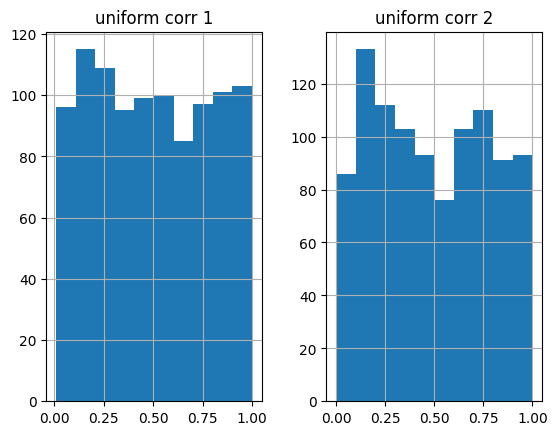

In [17]:
# generate two uniformly distributed features that are correlated with the target
# gen_correlated_uniform_series(original_series, correlation_coefficient=0, size=len(df))
df['uniform corr 1'] = gen_correlated_uniform_series(df['target'])
df['uniform corr 2'] = gen_correlated_uniform_series(df['target'])

print(df[['uniform corr 1', 'uniform corr 2', 'target']].corr())
df[['uniform corr 1', 'uniform corr 2']].hist();

In [18]:
# create two features that are duplicates of other features
df['duplicate_1'] = df['informative_1']
df['duplicate_2'] = df['informative_2']

In [19]:
# create two numerical features with outliers
df['outliers 1'] = gen_outliers(mean=0, std_dev=1, size=len(df), outlier_percentage=0.1, outlier_magnitude=3)
df['outliers 2'] = gen_outliers(mean=3, std_dev=2, size=len(df), outlier_percentage=0.2, outlier_magnitude=2)

In [20]:
# create a numerical feature that needs standard scaling
df['standard scaling'] = gen_standard_scaling()

In [21]:
# create a numerical feature that needs min max scaling
df['min max scaling'] = gen_minmax_scaling()

In [22]:
# generate null values
for col in df.drop(['class', 'informative_1', 'informative_2', 'target', 'duplicate_1', 'duplicate_2'], axis=1).columns:
    df[col] = gen_null(df[col], np.random.choice([0, 5, 10, 20, 30, 50], size=1).item())

In [23]:
# create two features that have constant values
df['constant_1'] = 'constant_value'
df['constant_2'] = 'constant_value'

In [24]:
# create two features with semi constant values
df['semi_constant_1'] = gen_quasi_constants('q_const', variation_percentage = 1)
df['semi_constant_2'] = gen_quasi_constants('q_const', variation_percentage = 1)

In [25]:
print(df.info())  # check your work

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   binary                 950 non-null    object  
 1   given_name             1000 non-null   object  
 2   surname                1000 non-null   object  
 3   date_of_birth          800 non-null    object  
 4   phone_number           950 non-null    object  
 5   email                  1000 non-null   object  
 6   address                452 non-null    object  
 7   city                   856 non-null    object  
 8   state                  731 non-null    object  
 9   zipcode                455 non-null    object  
 10  informative_1          1000 non-null   float64 
 11  informative_2          1000 non-null   float64 
 12  target                 1000 non-null   float64 
 13  class                  1000 non-null   int64   
 14  corr_feature_class     1000 non-null   fl

In [26]:
# add duplicates
dupes = df.loc[0:9]
df = pd.concat([df, dupes], axis=0)

# shuffle all columns
# df = df.sample(frac=1).reset_index(drop=True)
# df = df.sample(frac=1, axis=1)

# shuffle selected columns
demographic_columns = demographics.columns
remaining_columns = [col for col in df.columns if col not in demographic_columns]
# print(remaining_columns)
np.random.shuffle(remaining_columns)

# Reassemble the DataFrame with the shuffled columns
df = df[list(demographic_columns) + list(remaining_columns)]

# move target to the end of the list
class_var = 'class'
df = df[df.drop('class', axis=1).columns.tolist() + [class_var]]

print(df.shape)
print(df.info())
df.head()

(1010, 41)
<class 'pandas.core.frame.DataFrame'>
Index: 1010 entries, 0 to 9
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   binary                 959 non-null    object  
 1   given_name             1010 non-null   object  
 2   surname                1010 non-null   object  
 3   date_of_birth          808 non-null    object  
 4   phone_number           960 non-null    object  
 5   email                  1010 non-null   object  
 6   address                457 non-null    object  
 7   city                   866 non-null    object  
 8   state                  740 non-null    object  
 9   zipcode                460 non-null    object  
 10  multicollinearity 4    708 non-null    float64 
 11  pd qcut2               808 non-null    category
 12  outliers 2             907 non-null    float64 
 13  target                 1010 non-null   float64 
 14  multicollinearity 3    1010 non-null 

,binary,given_name,surname,date_of_birth,phone_number,email,address,city,state,zipcode,...,multicollinearity 1,semi_constant_2,outliers 1,constant_1,duplicate_1,random label num 3,random label num 14,duplicate_2,random choice 7,class
0,binary_1,Christina,Henderson,1952-01-09,(350)278-3741x1356,ryantapia@example.com,NaN,West Holly,RI,52928,...,-0.470507,q_const_0,0.066929,constant_value,-0.999102,label num lo 3,label num hi 5,-0.663860,Thursday,1
1,binary_2,Bryan,Smith,1926-12-28,001-890-473-5532x99372,ifitzpatrick@example.org,911 Ryan Shoal Apt. 351,North Heatherberg,KY,70082,...,0.337952,q_const_0,0.750603,constant_value,1.246686,label num lo 2,label num hi 4,1.153597,Monday,1
2,binary_2,Kevin,Tucker,1952-02-08,691.679.3920x5234,shannon14@example.com,NaN,East Jason,NJ,21311,...,0.656017,q_const_0,-1.299572,constant_value,0.962777,label num lo 3,label num hi 4,0.859397,Friday,1
3,binary_1,Elizabeth,Horne,1994-06-08,(919)463-4578,kimberly99@example.com,NaN,West Edwardside,MO,NaN,...,-0.596260,q_const_0,2.413705,constant_value,-2.957441,label num lo 3,label num hi 5,2.033645,Friday,1
4,binary_2,Matthew,Smith,NaN,+1-883-330-2667,robertsvirginia@example.net,NaN,East Bryan,NaN,02502,...,-0.312840,q_const_0,NaN,constant_value,1.141165,label num lo 3,label num hi 11,1.059449,Sunday,1


## Exploratory Data Analysis

Exploratory data analysis (EDA) is a data analysis method that helps data scientists understand their data and identify patterns. It's often used as the first step in data analysis.

### Correlation

In [27]:
# code along
df._get_numeric_data().corr().round(2)

,multicollinearity 4,outliers 2,target,multicollinearity 3,min max scaling,correlated w target 2,uniform corr 1,informative_1,uniform corr 2,informative_2,correlated w target 1,corr_feature_class,standard scaling,multicollinearity 2,multicollinearity 1,outliers 1,duplicate_1,duplicate_2,class
multicollinearity 4,1.00,0.04,-0.05,0.90,0.04,-0.01,-0.06,-0.01,-0.03,-0.05,-0.04,-0.01,-0.02,0.02,0.01,0.01,-0.01,-0.05,-0.02
outliers 2,0.04,1.00,0.02,0.05,0.04,0.00,0.01,0.05,-0.00,0.02,0.04,0.06,0.07,-0.00,-0.04,0.00,0.05,0.02,0.02
target,-0.05,0.02,1.00,-0.03,-0.06,0.70,0.69,-0.03,0.70,0.99,0.53,0.32,-0.03,-0.08,-0.09,0.03,-0.03,0.99,0.72
multicollinearity 3,0.90,0.05,-0.03,1.00,0.05,-0.03,-0.02,-0.04,-0.03,-0.04,-0.02,-0.01,-0.03,0.00,-0.01,-0.00,-0.04,-0.04,0.00
min max scaling,0.04,0.04,-0.06,0.05,1.00,-0.08,-0.06,0.01,-0.05,-0.05,-0.03,0.06,0.05,-0.06,-0.10,0.10,0.01,-0.05,-0.03
correlated w target 2,-0.01,0.00,0.70,-0.03,-0.08,1.00,0.48,-0.02,0.51,0.70,0.38,0.22,-0.03,-0.08,-0.10,0.07,-0.02,0.70,0.52
uniform corr 1,-0.06,0.01,0.69,-0.02,-0.06,0.48,1.00,-0.04,0.47,0.68,0.39,0.23,-0.02,-0.03,-0.04,0.02,-0.04,0.68,0.52
informative_1,-0.01,0.05,-0.03,-0.04,0.01,-0.02,-0.04,1.00,-0.03,0.10,0.00,-0.00,0.00,-0.03,0.03,-0.06,1.00,0.10,-0.01
uniform corr 2,-0.03,-0.00,0.70,-0.03,-0.05,0.51,0.47,-0.03,1.00,0.69,0.36,0.25,0.01,-0.04,-0.07,0.01,-0.03,0.69,0.52
informative_2,-0.05,0.02,0.99,-0.04,-0.05,0.70,0.68,0.10,0.69,1.00,0.53,0.32,-0.03,-0.09,-0.09,0.02,0.10,1.00,0.72


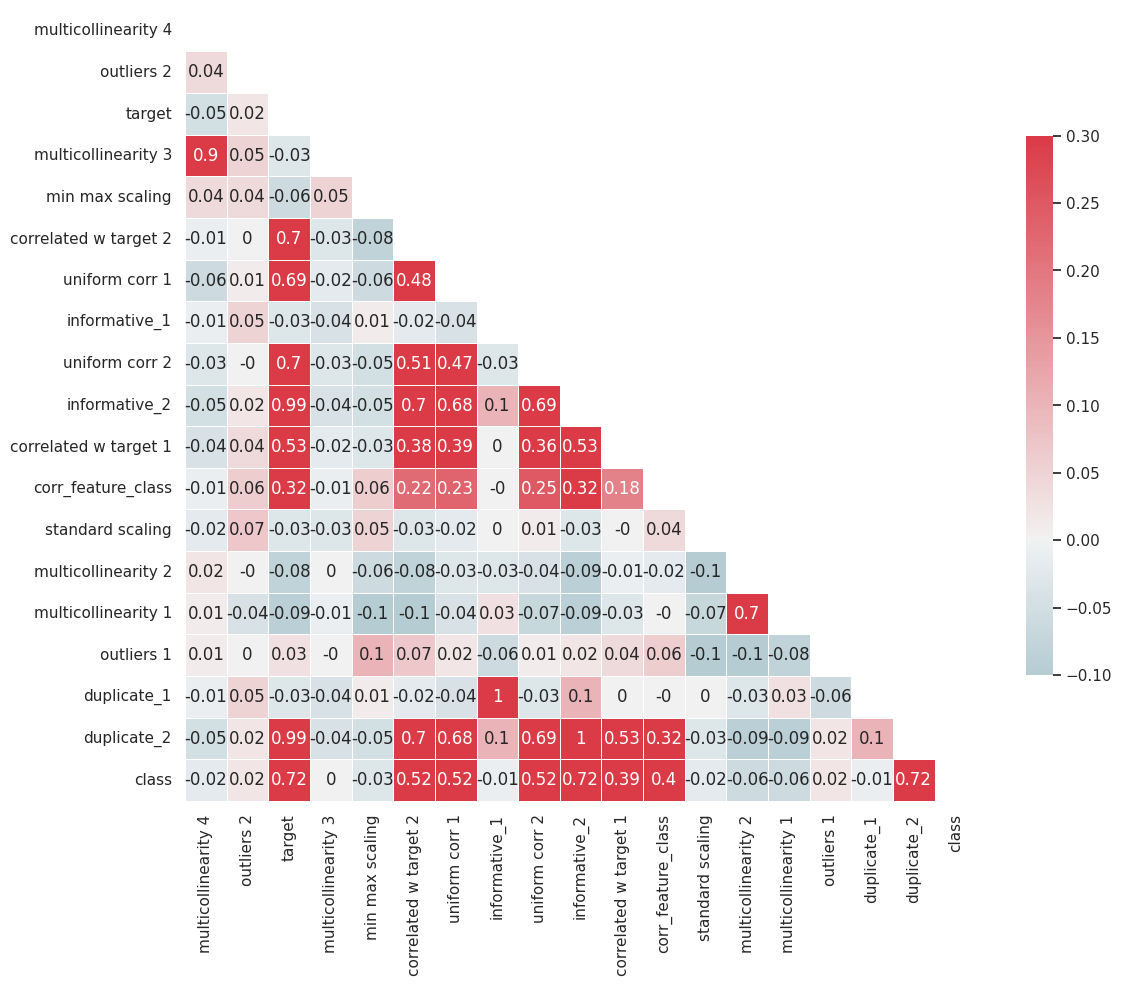

In [28]:
# show correlation between the features
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# correlation matrix
sns.set(style="white")

# compute the correlation matrix
corr = df._get_numeric_data().corr().round(2)

# generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# set up the matplotlib figure
# f, ax = plt.subplots()
f = plt.figure(figsize=(12, 12))

# generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True);

plt.tight_layout()

In [29]:
# calculate the correlation matrix
corr_matrix = df._get_numeric_data().corr()

# Create a mask for the upper triangle (to avoid duplicates)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Convert the correlation matrix to a long format
corr_df = corr_matrix.stack().reset_index()
corr_df.columns = ['feature1', 'feature2', 'correlation']

# Filter for correlations above a certain threshold (e.g., 0.7)
high_corr_df = corr_df[(abs(corr_df['correlation']) > 0.7) & (corr_df['feature1'] != corr_df['feature2'])]

# Sort by absolute correlation in descending order
high_corr_df = high_corr_df.sort_values(by='correlation', ascending=False, key=abs)

# Print the top correlated features
# print(high_corr_df['feature1'].to_list()[4:10])
print(high_corr_df)

                  feature1               feature2  correlation
149          informative_1            duplicate_1     1.000000
188          informative_2            duplicate_2     1.000000
332            duplicate_2          informative_2     1.000000
311            duplicate_1          informative_1     1.000000
325            duplicate_2                 target     0.991500
47                  target          informative_2     0.991500
55                  target            duplicate_2     0.991500
173          informative_2                 target     0.991500
3      multicollinearity 4    multicollinearity 3     0.895110
57     multicollinearity 3    multicollinearity 4     0.895110
56                  target                  class     0.722662
344                  class                 target     0.722662
351                  class          informative_2     0.717481
341            duplicate_2                  class     0.717481
189          informative_2                  class     0

In [30]:
# check for vif
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# handle null values (using mean imputation for simplicity)
x_copy = df.drop('class', axis=1)._get_numeric_data()
x_copy.fillna(x_copy.mean(), inplace=True)

print(max([variance_inflation_factor(x_copy, i) for i in range(x_copy.shape[1])]))

# calculate VIF
vif = pd.DataFrame()
vif["Variable"] = x_copy.columns
vif["VIF"] = [variance_inflation_factor(x_copy, i) for i in range(x_copy.shape[1])]
print(vif)

/usr/local/lib/python3.10/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


inf
                 Variable           VIF
0     multicollinearity 4  2.206436e+00
1              outliers 2  1.014044e+00
2                  target  1.757399e+04
3     multicollinearity 3  2.208101e+00
4         min max scaling  1.017854e+00
5   correlated w target 2  1.695223e+00
6          uniform corr 1  1.751945e+00
7           informative_1           inf
8          uniform corr 2  1.816302e+00
9           informative_2           inf
10  correlated w target 1  1.347065e+00
11     corr_feature_class  1.128622e+00
12       standard scaling  1.016925e+00
13    multicollinearity 2  1.794264e+00
14    multicollinearity 1  1.797007e+00
15             outliers 1  1.027911e+00
16            duplicate_1           inf
17            duplicate_2           inf


/usr/local/lib/python3.10/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


### Multicollinearity

* We want high correlation with target
* We don't want high correlation between features
* Drop correlated features
* Combine correlated features

In [31]:
# # create a new variable by combining two variables
# df['scaling_combined'] = df['standard scaling'] + df['min max scaling']
# df.drop(['standard scaling', 'min max scaling'], axis=1, inplace=True)

In [32]:
# iterate dropping features with high vif
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

removed1=[]
x_copy1 = x_copy.copy()
max_vif = thresh = 10
while max_vif >= thresh:
  my_list = [variance_inflation_factor(x_copy1, i) for i in range(x_copy1.shape[1])]
  max_vif = max(my_list)
  if max_vif > thresh:
    max_index = my_list.index(max_vif)
    removed1.append(x_copy1.columns[max_index])
    print(x_copy1.columns[max_index], variance_inflation_factor(x_copy1, max_index))
    x_copy1.drop(x_copy1.columns[max_index], axis=1, inplace=True)


# Calculate VIF
vif = pd.DataFrame()
vif["Variable"] = x_copy1.columns
vif["VIF"] = [variance_inflation_factor(x_copy1, i) for i in range(x_copy1.shape[1])]
print(vif)

/usr/local/lib/python3.10/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


informative_1 inf
informative_2 inf


/usr/local/lib/python3.10/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


target 17573.98789965453
standard scaling 26.96749624124511
min max scaling 10.908216649237966
                 Variable       VIF
0     multicollinearity 4  2.208978
1              outliers 2  2.731457
2     multicollinearity 3  2.219023
3   correlated w target 2  1.711552
4          uniform corr 1  4.568556
5          uniform corr 2  4.589269
6   correlated w target 1  1.355786
7      corr_feature_class  1.628270
8     multicollinearity 2  1.788564
9     multicollinearity 1  1.795563
10             outliers 1  1.018222
11            duplicate_1  1.053642
12            duplicate_2  2.287570


In [33]:
# check again vif
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

removed2=[]
max_vif = thresh = 10
while max_vif >= thresh:
  max_vif = max([variance_inflation_factor(x_copy, i) for i in range(x_copy.shape[1])])
  for i in range(x_copy.shape[1]):
    if variance_inflation_factor(x_copy, i) > thresh:
      removed2.append(x_copy.columns[i])
      print(x_copy.columns[i], variance_inflation_factor(x_copy, i))
      x_copy.drop(x_copy.columns[i], axis=1, inplace=True)
      break

# Calculate VIF
vif = pd.DataFrame()
vif["Variable"] = x_copy.columns
vif["VIF"] = [variance_inflation_factor(x_copy, i) for i in range(x_copy.shape[1])]
print(vif)

/usr/local/lib/python3.10/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


target 17573.98789965453


/usr/local/lib/python3.10/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.10/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


min max scaling 23.23370513764893
informative_1 inf


/usr/local/lib/python3.10/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


informative_2 inf
standard scaling 12.661230300729354
                 Variable       VIF
0     multicollinearity 4  2.208978
1              outliers 2  2.731457
2     multicollinearity 3  2.219023
3   correlated w target 2  1.711552
4          uniform corr 1  4.568556
5          uniform corr 2  4.589269
6   correlated w target 1  1.355786
7      corr_feature_class  1.628270
8     multicollinearity 2  1.788564
9     multicollinearity 1  1.795563
10             outliers 1  1.018222
11            duplicate_1  1.053642
12            duplicate_2  2.287570


In [34]:
print(removed1)
print(removed2)

['informative_1', 'informative_2', 'target', 'standard scaling', 'min max scaling']
['target', 'min max scaling', 'informative_1', 'informative_2', 'standard scaling']


### Outliers

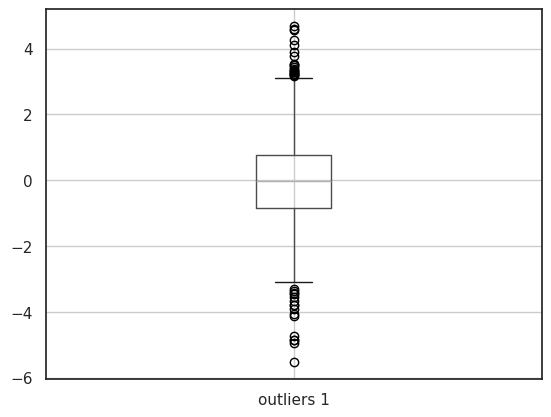

In [35]:
# code along
df.boxplot(column=['outliers 1']);

In [36]:
# code along
df.describe()

,multicollinearity 4,outliers 2,target,multicollinearity 3,min max scaling,correlated w target 2,uniform corr 1,informative_1,uniform corr 2,informative_2,correlated w target 1,corr_feature_class,standard scaling,multicollinearity 2,multicollinearity 1,outliers 1,duplicate_1,duplicate_2,class
count,708.000000,907.000000,1010.000000,1010.000000,506.000000,808.000000,910.000000,1010.000000,908.000000,1010.000000,909.000000,1010.000000,506.000000,958.000000,960.000000,809.000000,1010.000000,1010.000000,1010.000000
mean,0.031586,2.941934,0.195609,0.076110,399.962920,0.307388,0.490969,-0.047372,0.488913,-0.018978,0.234780,2.009343,50035.580779,-0.033369,-0.048522,-0.018483,-0.047372,-0.018978,0.502970
std,0.960694,2.121761,2.991347,0.983403,98.433942,3.043942,0.287446,1.324010,0.287934,1.403413,3.011074,2.899641,9891.936589,1.027030,0.999420,1.391567,1.324010,1.403413,0.500239
min,-3.335093,-3.580166,-8.943212,-3.001646,111.356814,-9.689721,0.007527,-3.836929,0.001370,-4.543441,-10.505581,-12.441779,20695.183263,-3.060815,-3.807248,-5.523849,-3.836929,-4.543441,0.000000
25%,-0.638134,1.568160,-2.166961,-0.648018,331.927403,-1.822304,0.240164,-1.018399,0.232090,-1.050339,-1.862155,0.354343,43569.080097,-0.733262,-0.669004,-0.834530,-1.018399,-1.050339,0.000000
50%,0.005287,2.955113,-0.011259,0.072065,400.521682,0.349339,0.482299,-0.224366,0.462723,-0.194004,0.193419,2.046803,50506.944825,-0.023707,-0.048483,-0.024469,-0.224366,-0.194004,1.000000
75%,0.601955,4.369166,2.367192,0.726387,472.866656,2.439192,0.748239,0.975364,0.741328,0.991017,2.383178,3.714000,56186.591150,0.659462,0.616393,0.771236,0.975364,0.991017,1.000000
max,3.228562,8.871912,9.299296,3.214038,674.514144,9.629811,0.999953,3.994644,0.999360,4.020262,10.553812,16.322976,78842.763915,3.028924,3.103971,4.687139,3.994644,4.020262,1.000000


In [37]:
# code along
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1010 entries, 0 to 9
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   binary                 959 non-null    object  
 1   given_name             1010 non-null   object  
 2   surname                1010 non-null   object  
 3   date_of_birth          808 non-null    object  
 4   phone_number           960 non-null    object  
 5   email                  1010 non-null   object  
 6   address                457 non-null    object  
 7   city                   866 non-null    object  
 8   state                  740 non-null    object  
 9   zipcode                460 non-null    object  
 10  multicollinearity 4    708 non-null    float64 
 11  pd qcut2               808 non-null    category
 12  outliers 2             907 non-null    float64 
 13  target                 1010 non-null   float64 
 14  multicollinearity 3    1010 non-null   float64 


## Data Prep

https://www.udemy.com/course/feature-engineering-for-machine-learning

* Types and characteristics of data
* Missing data imputation
* Categorical encoding
* Variable transformation
* Discretization
* Outliers
* Datetime
* Scaling
* Feature creation

In [38]:
# ! git clone https://github.com/gitmystuff/preppy.git

In [39]:
# import shutil

# # Source file path (within your Drive)
# source_file = '/content/drive/MyDrive/DTSC5502/Project CICD/preppy report.py'

# # Destination path (root of your Drive)
# destination_path = '/content/preppy/utils/report.py'

# # Copy the file
# shutil.copy(source_file, destination_path)

In [40]:
import preppy.utils as utils
from preppy.version import __version__

print(__version__)

utils.report.write_report(df, thresh=.5)

PrepPy Version: 0.1.0
REPORT FOR DATA PREP

#################################################
Columns with Constant Values
#################################################
['constant_2', 'constant_1']

#################################################
Columns with Quasi-Constant Values
#################################################
['class', 'constant_1', 'constant_2']

#################################################
Duplicate Rows
#################################################
20

#################################################
Duplicate Columns
#################################################
['constant_1', 'duplicate_1', 'duplicate_2']

#################################################
Variables with Noticeably Higher Scales
#################################################
Features with Noticeably Higher Scales (Based on Standard Deviation):
standard scaling    9891.936589
Name: std, dtype: float64

Features with Noticeably Higher Scales (Based on Range):
standard scali

## Feature Engineering

In [41]:
df_numerical = df.select_dtypes(include='number').columns
df_object = df.select_dtypes(include=['object']).columns
df_discreet = df.select_dtypes(include=['category']).columns
df_categorical_features = df.select_dtypes(include=['category', 'object']).columns
df_discreet

Index(['pd qcut2', 'pd qcut1', 'pd qcut3'], dtype='object')

### Pipeline

### BaseEstimator, TransformerMixin

Imagine you're building a machine to process and transform data. `BaseEstimator` and `TransformerMixin` are like instruction manuals that help your machine understand how to work with different parts of the data.

**`BaseEstimator`**

*   Provides basic tools:** This is like a toolbox with essential tools for your machine. It provides methods for getting and setting parameters (like knobs and switches on your machine) and for cloning the machine (making a copy of it).

**`TransformerMixin`**

*   Handles transformations:** This manual teaches your machine how to transform data. It provides a method called `fit_transform` that combines two steps:
    *   **`fit`:**  The machine learns something about the data (like figuring out the average value).
    *   **`transform`:** The machine uses what it learned to change the data (like subtracting the average value from each data point).

**Why use them with pipeline transformers?**

*   **Compatibility:** When you build custom transformers (special parts for your machine) and want to use them in a scikit-learn pipeline (a series of connected machines), inheriting from `BaseEstimator` and `TransformerMixin` ensures that your custom parts fit seamlessly with the other machines in the pipeline.
*   **Convenience:** `TransformerMixin` provides the handy `fit_transform` method, which streamlines the process of fitting and transforming data in one step.

**In simple terms**

`BaseEstimator` and `TransformerMixin` are like blueprints that help you build standardized and compatible parts for your data processing machine (pipeline), making it easier to manage and transform your data.

In [42]:
from sklearn.base import BaseEstimator, TransformerMixin
import inspect

print(dir(BaseEstimator))
print(dir(TransformerMixin))

print(BaseEstimator.__dict__)

print(inspect.getmembers(BaseEstimator))


['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__str__', '__subclasshook__', '__weakref__', '_build_request_for_signature', '_check_feature_names', '_check_n_features', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_get_default_requests', '_get_doc_link', '_get_metadata_request', '_get_param_names', '_get_tags', '_more_tags', '_repr_html_', '_repr_html_inner', '_repr_mimebundle_', '_validate_data', '_validate_params', 'get_metadata_routing', 'get_params', 'set_params']
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__'

In [43]:
import pprint

pprint.pprint(inspect.getmembers(BaseEstimator))

[('__class__', <class 'type'>),
 ('__delattr__', <slot wrapper '__delattr__' of 'object' objects>),
 ('__dict__',
  mappingproxy({'__doc__': 'Base class for all estimators in scikit-learn.\n'
                           '\n'
                           '    Inheriting from this class provides default '
                           'implementations of:\n'
                           '\n'
                           '    - setting and getting parameters used by '
                           '`GridSearchCV` and friends;\n'
                           '    - textual and HTML representation displayed in '
                           'terminals and IDEs;\n'
                           '    - estimator serialization;\n'
                           '    - parameters validation;\n'
                           '    - data validation;\n'
                           '    - feature names validation.\n'
                           '\n'
                           '    Read more in the :ref:`User Guide '
          

In [44]:
import numpy as np

df_numerical = df.select_dtypes(exclude=['category', 'object']).columns.to_list()
df_object = df.select_dtypes(include=['object']).columns.to_list()
df_discreet = df.select_dtypes(include=['category']).columns.to_list()
df_categorical_features = df.select_dtypes(include=['category', 'object']).columns.to_list()


In [45]:
import preppy.utils as preppy

consts = preppy.functions.identify_consts(df)
quasi_consts = preppy.functions.identify_quasi_consts(df)
duplicates = preppy.functions.check_col_duplicates(df)
print(duplicates)
print(consts)
print(quasi_consts)

['constant_1', 'duplicate_1', 'duplicate_2']
['constant_2', 'constant_1']
['constant_1', 'constant_2']


In [46]:
# numeric_df = df.apply(pd.to_numeric, errors='coerce')
all_deletes = list(set(consts + quasi_consts + duplicates))
for col in all_deletes:
  print(col, df[col].dtype)
  if df[col].dtype in ['float64', 'int64']:
    df_numerical.remove(col)
  elif df[col].dtype in ['object']:
    df_object.remove(col)
    df_categorical_features.remove(col)
  else:
    df_discreet.remove(col)


duplicate_2 float64
duplicate_1 float64
constant_2 object
constant_1 object


In [47]:
import pickle

# Create a variable to pickle
data = {'df_numerical': df_numerical, 'df_object': df_object, 'df_discreet': df_discreet, 'df_categorical_features': df_categorical_features}

# Pickle the variable and save it to a file
with open('var_types.pickle', 'wb') as f:
    pickle.dump(data, f)

In [48]:
import pickle

# Load the pickled variable from the file
with open('var_types.pickle', 'rb') as f:
    var_types = pickle.load(f)

print(var_types)

{'df_numerical': ['multicollinearity 4', 'outliers 2', 'target', 'multicollinearity 3', 'min max scaling', 'correlated w target 2', 'uniform corr 1', 'informative_1', 'uniform corr 2', 'informative_2', 'correlated w target 1', 'corr_feature_class', 'standard scaling', 'multicollinearity 2', 'multicollinearity 1', 'outliers 1', 'class'], 'df_object': ['binary', 'given_name', 'surname', 'date_of_birth', 'phone_number', 'email', 'address', 'city', 'state', 'zipcode', 'random choice 4', 'random choice 2', 'semi_constant_1', 'semi_constant_2', 'random label num 3', 'random label num 14', 'random choice 7'], 'df_discreet': ['pd qcut2', 'pd qcut1', 'pd qcut3'], 'df_categorical_features': ['binary', 'given_name', 'surname', 'date_of_birth', 'phone_number', 'email', 'address', 'city', 'state', 'zipcode', 'pd qcut2', 'random choice 4', 'pd qcut1', 'random choice 2', 'semi_constant_1', 'pd qcut3', 'semi_constant_2', 'random label num 3', 'random label num 14', 'random choice 7']}


In [49]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
import preppy.utils as preppy

pipe = [
    ('constants', preppy.classes.RemoveConstants()),
    ('quasiconsts', preppy.classes.RemoveQuasiConstants(thresh=0.8)),
    ('duplicates', preppy.classes.DropDuplicates()),
    ('missing', preppy.classes.HandleMissingValues()),
    # ('encoding', HandleCatEncodeing())
]

pipe_model = Pipeline(pipe)
data = pipe_model.fit_transform(df)
cols = [col for col in df.columns if col not in consts + quasi_consts + duplicates]
nu_df = pd.DataFrame(data, columns=cols)
nu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 37 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   binary                 1000 non-null   object
 1   given_name             1000 non-null   object
 2   surname                1000 non-null   object
 3   date_of_birth          1000 non-null   object
 4   phone_number           1000 non-null   object
 5   email                  1000 non-null   object
 6   address                1000 non-null   object
 7   city                   1000 non-null   object
 8   state                  1000 non-null   object
 9   zipcode                1000 non-null   object
 10  multicollinearity 4    1000 non-null   object
 11  pd qcut2               1000 non-null   object
 12  outliers 2             1000 non-null   object
 13  target                 1000 non-null   object
 14  multicollinearity 3    1000 non-null   object
 15  min max scaling       

/content/preppy/utils/functions.py:61: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfx[feat] = df[feat].fillna(df[feat].mode()[0])


In [50]:
df_numerical = var_types['df_numerical']
df_object = var_types['df_object']
df_discreet = var_types['df_discreet']
df_categorical_features = var_types['df_categorical_features']

In [51]:
# code along
nu_df[df_numerical] = nu_df[df_numerical].astype(float)
nu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 37 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   binary                 1000 non-null   object 
 1   given_name             1000 non-null   object 
 2   surname                1000 non-null   object 
 3   date_of_birth          1000 non-null   object 
 4   phone_number           1000 non-null   object 
 5   email                  1000 non-null   object 
 6   address                1000 non-null   object 
 7   city                   1000 non-null   object 
 8   state                  1000 non-null   object 
 9   zipcode                1000 non-null   object 
 10  multicollinearity 4    1000 non-null   float64
 11  pd qcut2               1000 non-null   object 
 12  outliers 2             1000 non-null   float64
 13  target                 1000 non-null   float64
 14  multicollinearity 3    1000 non-null   float64
 15  min m

### Categorical Encoding

In [52]:
# code along
import preppy.utils as utils

nu_df = utils.functions.do_OHE(nu_df)
nu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 44 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   binary                             1000 non-null   int64  
 1   given_name                         1000 non-null   float64
 2   surname                            1000 non-null   float64
 3   date_of_birth                      1000 non-null   float64
 4   phone_number                       1000 non-null   float64
 5   email                              1000 non-null   float64
 6   address                            1000 non-null   float64
 7   city                               1000 non-null   float64
 8   state                              1000 non-null   float64
 9   zipcode                            1000 non-null   float64
 10  multicollinearity 4                1000 non-null   float64
 11  outliers 2                         1000 non-null   float6

In [53]:
# nu_df.to_csv('make_me_data_science_v.csv', index=False)

In [54]:
# import shutil

# # Source file path (within your Drive)
# source_file = '/content/make_me_data_science_v.csv'

# # Destination path (root of your Drive)
# destination_path = '/content/drive/MyDrive/Project CICD/'

# # Copy the file
# shutil.copy(source_file, destination_path)

## Feature Selection

In [55]:
# # get data - required cell but find your own path
# import pandas as pd

# df = pd.read_csv('/content/drive/MyDrive/Project CICD/make_me_data_science_v.csv')
# print(df.shape)
# print(df.info())
# df.head()

### Cardinality

<pre>
df_numerical = df.select_dtypes(include='number').columns
df_object = df.select_dtypes(include=['object']).columns
df_discreet = df.select_dtypes(include=['category']).columns
df_categorical_features = df.select_dtypes(include=['category', 'object']).columns
</pre>

In [56]:
# import pickle

# # Load the pickled variable from the file
# with open('var_types.pickle', 'rb') as f:
#     var_types = pickle.load(f)

# df_numerical = var_types['df_numerical']
# df_object = var_types['df_object']
# df_discreet = var_types['df_discreet']
# df_categorical_features = var_types['df_categorical_features']

### Train Test Split

* Use random_state=random_state

List the features (5 at the most) that you will be using and justify why you are using them.



## Data Modeling

### Logistic Regression

### Random Forest

## Model Evaluation

### Precision Recall

* See Precision Recall Notebook

### Bias Variance

* See Bias Variance Tradeoff Notebook

### Confusion Matrix

* See Confusion Matrix Notebooks

## Model Fine-Tuning

### Cross Validation

* See Cross Validation Notebook

### Final Model

## Model Deployment